<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Assignment_18_optional_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Data Loading & Initial Analysis

In [2]:
# Import pandas library
import pandas as pd

# Load the Insurance Dataset
df = pd.read_csv("insurance.csv")

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display last 5 rows
print("\nLast 5 Rows:")
print(df.tail())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)

First 10 Rows:
   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86
5   31  female  25.7         0     no  southeast   3756.62
6   46  female  33.4         1     no  southeast   8240.59
7   37  female  27.7         3     no  northwest   7281.51
8   37    male  29.8         2     no  northeast   6406.41
9   60  female  25.8         0     no  northwest  28923.14

Last 5 Rows:
      age     sex   bmi  children smoker     region  expenses
1333   50    male  31.0         3     no  northwest  10600.55
1334   18  female  31.9         0     no  northeast   2205.98
1335   18  female  36.9         0     no  southeast   1629.83
1336   21  female  25.8         0     no  southwest   2007.95
1337   61  f

Q2. Missing Values & Duplicate Values

In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Display new shape
print("\nShape After Removing Duplicates:")
print(df.shape)

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

Duplicate Rows:
1

Shape After Removing Duplicates:
(1337, 7)


Q3. Statistical Summary

In [ ]:
# Display statistical summary
print(df.describe())

# Age Statistics
print("\nAge Statistics")
print("Mean:", df["age"].mean())
print("Median:", df["age"].median())
print("Minimum:", df["age"].min())
print("Maximum:", df["age"].max())

# BMI Statistics
print("\nBMI Statistics")
print("Mean:", df["bmi"].mean())
print("Median:", df["bmi"].median())
print("Minimum:", df["bmi"].min())
print("Maximum:", df["bmi"].max())

# Expenses Statistics
print("\nExpenses Statistics")
print("Mean:", df["expenses"].mean())
print("Median:", df["expenses"].median())
print("Minimum:", df["expenses"].min())
print("Maximum:", df["expenses"].max())

               age          bmi     children      expenses
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.665520     1.095737  13279.121638
std      14.044333     6.100664     1.205571  12110.359657
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4746.340000
50%      39.000000    30.400000     1.000000   9386.160000
75%      51.000000    34.700000     2.000000  16657.720000
max      64.000000    53.100000     5.000000  63770.430000

Age Statistics
Mean: 39.222139117427076
Median: 39.0
Minimum: 18
Maximum: 64

BMI Statistics
Mean: 30.665519820493646
Median: 30.4
Minimum: 16.0
Maximum: 53.1

Expenses Statistics
Mean: 13279.121637995511
Median: 9386.16
Minimum: 1121.87
Maximum: 63770.43


Q4. Histogram of Numeric Features (All Graphs in One Canvas)

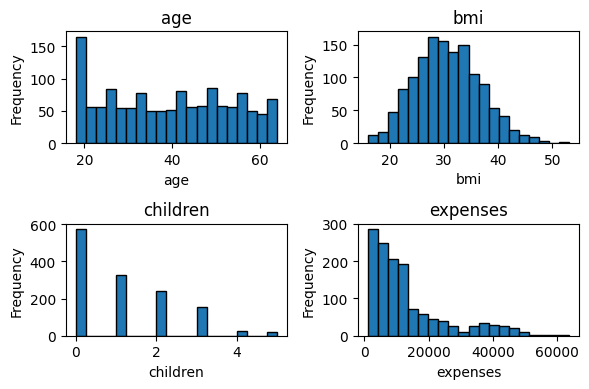

In [ ]:
import matplotlib.pyplot as plt

# Numerical columns
numeric_columns = ['age', 'bmi', 'children', 'expenses']

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(6, 4))

axes = axes.ravel()

for i, column in enumerate(numeric_columns):
    axes[i].hist(df[column], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Q5. Count Plots of Categorical Features

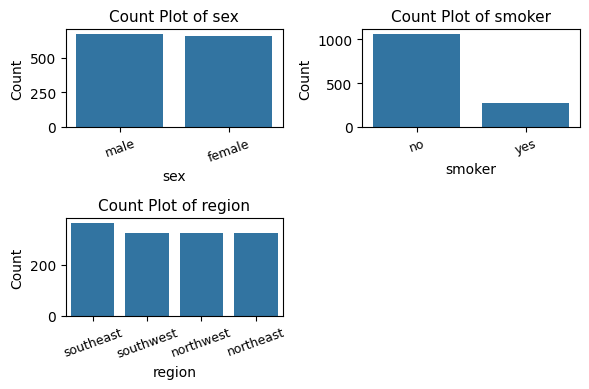

In [ ]:
# Q5. Count Plots of Categorical Features (One Canvas)

import matplotlib.pyplot as plt
import seaborn as sns

# List of categorical columns
categorical_columns = ['sex', 'smoker', 'region']

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(6, 4))

# Convert axes to a 1D array
axes = axes.flatten()

# Plot count plots
for i, column in enumerate(categorical_columns):

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index,
        ax=axes[i]
    )

    axes[i].set_title(f'Count Plot of {column}', fontsize=11)
    axes[i].set_xlabel(column, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)

    # Rotate labels if needed
    axes[i].tick_params(axis='x', rotation=20, labelsize=9)

# Hide the last empty subplot
axes[3].axis('off')

# Adjust spacing automatically
plt.tight_layout()

# Display plots
plt.show()

Q6. Correlation Heatmap

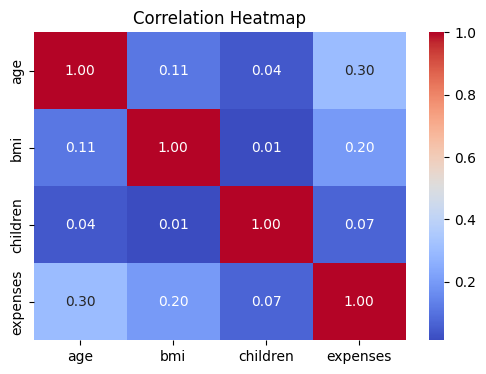

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
correlation = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
print("Correlation with Expenses:")
print(correlation["expenses"].sort_values(ascending=False))

Correlation with Expenses:
expenses    1.000000
age         0.298308
bmi         0.198637
children    0.067389
Name: expenses, dtype: float64


Q7. Feature Identification

In [ ]:
# Independent Features (Input Features)
X = df.drop("expenses", axis=1)

# Dependent Feature (Output Feature)
y = df["expenses"]

print("Independent Features (X):")
print(X.columns)

print("\nDependent Feature (y):")
print(y.name)

Independent Features (X):
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

Dependent Feature (y):
expenses


Q8. Encoding Categorical Variables (One-Hot Encoding)

In [ ]:
# Display categorical columns before encoding
print("Before Encoding:")
print(df[['sex', 'smoker', 'region']].head())

Before Encoding:
      sex smoker     region
0  female    yes  southwest
1    male     no  southeast
2    male     no  southeast
3    male     no  northwest
4    male     no  northwest


In [ ]:
# One-Hot Encoding
encoded_df = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

print("\nAfter Encoding:")
print(encoded_df.head())


After Encoding:
   age   bmi  children  expenses  sex_male  smoker_yes  region_northwest  \
0   19  27.9         0  16884.92     False        True             False   
1   18  33.8         1   1725.55      True       False             False   
2   28  33.0         3   4449.46      True       False             False   
3   33  22.7         0  21984.47      True       False              True   
4   32  28.9         0   3866.86      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:
print("Columns Before Encoding:")
print(df.columns)

print("\nColumns After Encoding:")
print(encoded_df.columns)

Columns Before Encoding:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

Columns After Encoding:
Index(['age', 'bmi', 'children', 'expenses', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


Q9. Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate input and output
X = encoded_df.drop("expenses", axis=1)
y = encoded_df["expenses"]

# Numerical columns
numerical_columns = ['age', 'bmi', 'children']

# Apply Standard Scaling
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

print("First 5 Rows of Scaled Data:")
print(X.head())

First 5 Rows of Scaled Data:
        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.440418 -0.453484 -0.909234     False        True             False   
1 -1.511647  0.513986 -0.079442      True       False             False   
2 -0.799350  0.382803  1.580143      True       False             False   
3 -0.443201 -1.306169 -0.909234      True       False              True   
4 -0.514431 -0.289506 -0.909234      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


Q10. Complete Preprocessing Pipeline

Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


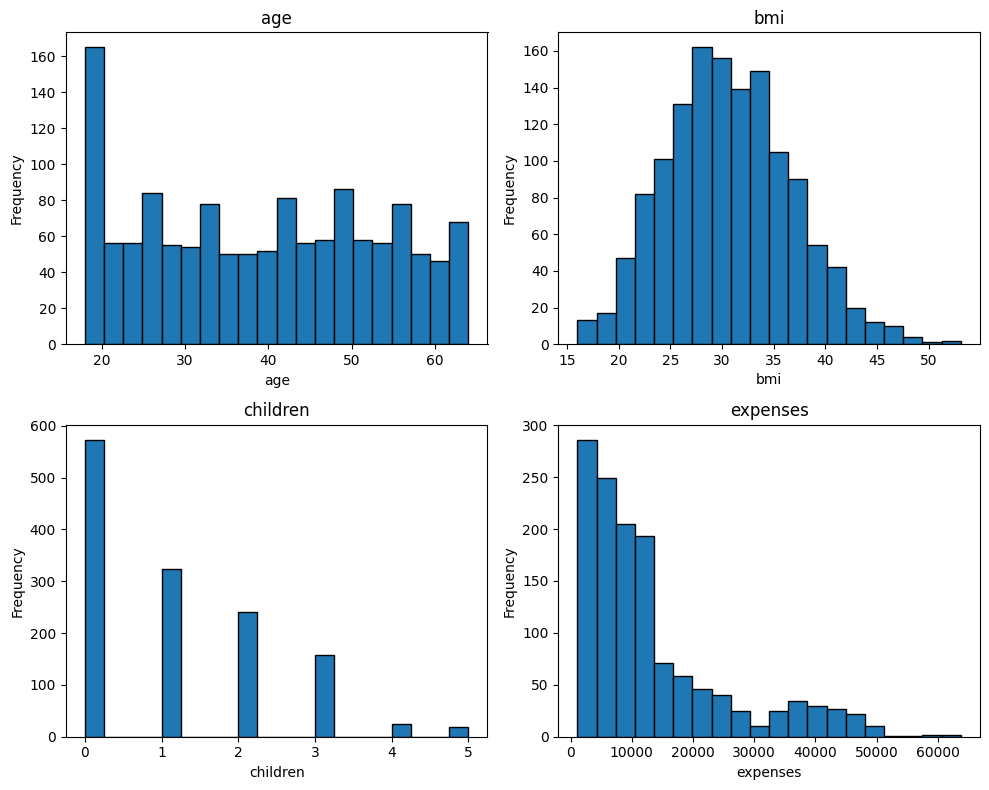

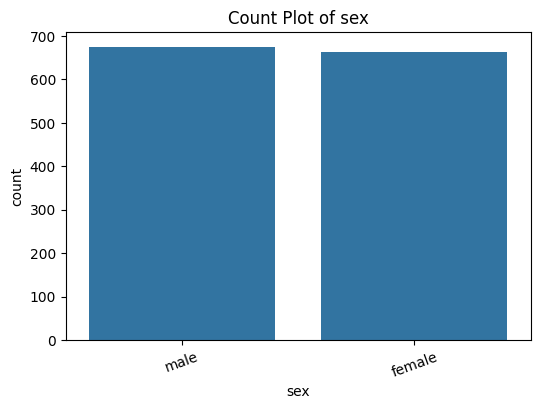

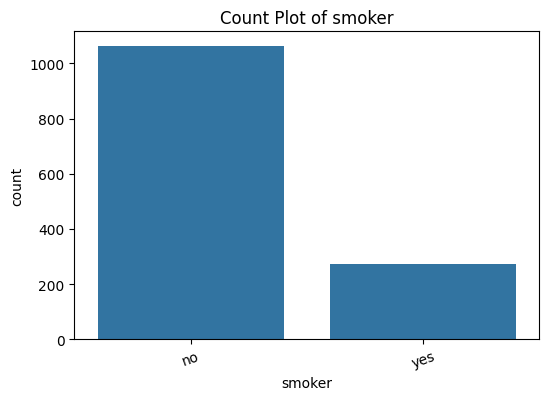

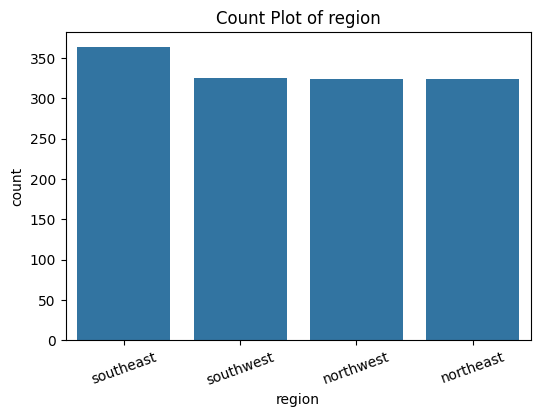

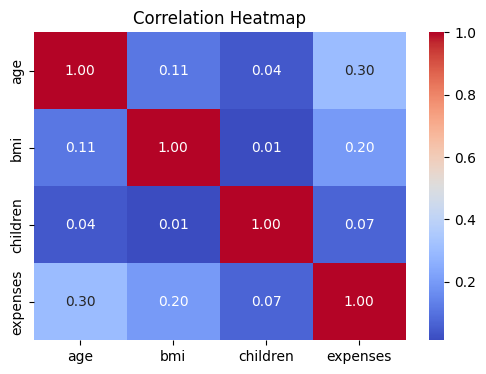


Preprocessing Completed Successfully

Final Shape of Input Features:
(1337, 8)

Target Shape:
(1337,)

First 5 Rows of Processed Data:
        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.440418 -0.453484 -0.909234     False        True             False   
1 -1.511647  0.513986 -0.079442      True       False             False   
2 -0.799350  0.382803  1.580143      True       False             False   
3 -0.443201 -1.306169 -0.909234      True       False              True   
4 -0.514431 -0.289506 -0.909234      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:
# ===========================================
# COMPLETE PREPROCESSING PIPELINE
# Insurance Dataset
# ===========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Step 1 : Load Dataset
df = pd.read_csv("insurance.csv")

# Step 2 : Check Missing Values
print("Missing Values")
print(df.isnull().sum())

# Step 3 : Remove Duplicate Rows
df = df.drop_duplicates()

# Step 4 : Histograms
numeric_columns = ['age', 'bmi', 'children', 'expenses']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, column in enumerate(numeric_columns):
    axes[i].hist(df[column], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Step 5 : Count Plots
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Count Plot of {column}")
    plt.xticks(rotation=20)
    plt.show()

# Step 6 : Correlation Heatmap
plt.figure(figsize=(6,4))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Step 7 : Identify Features
X = df.drop("expenses", axis=1)
y = df["expenses"]

# Step 8 : One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

# Step 9 : Standard Scaling
scaler = StandardScaler()

num_cols = ['age', 'bmi', 'children']

X[num_cols] = scaler.fit_transform(X[num_cols])

print("\nPreprocessing Completed Successfully")

print("\nFinal Shape of Input Features:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

print("\nFirst 5 Rows of Processed Data:")
print(X.head())